<a href="https://colab.research.google.com/github/springboardmentorLive/Reality_AI/blob/ananyarohidasshet/IS_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#loading data set
data = pd.read_csv('/content/large_customer_wholesale.csv')
data.head()

,Customer_ID,Customer_Name,Region,Product,Quantity,Unit_Price,Total_Amount,Purchase_Date
0,C1000,Global Stores,North,Tea Powder,494,1063,525122,2025-09-27
1,C1001,Mehta Distributors,North,Tea Powder,117,874,102258,2025-02-20
2,C1002,Metro Cash,South,Chocolates,198,1029,203742,2025-12-11
3,C1003,Metro Cash,West,Soap,189,801,151389,2025-06-24
4,C1004,Deepam Stores,South,Oil Tin,329,1199,394471,2025-04-02


In [ ]:
#normalizing the data to scale each variable as same weightage
from sklearn.preprocessing import normalize

# Select only numeric columns for normalization
numeric_cols = data.select_dtypes(include=np.number)
data_scaled = normalize(numeric_cols)
data_scaled = pd.DataFrame(data_scaled, columns=numeric_cols.columns)
data_scaled.head()

,Quantity,Unit_Price,Total_Amount
0,0.000941,0.002024,0.999998
1,0.001144,0.008547,0.999963
2,0.000972,0.005050,0.999987
3,0.001248,0.005291,0.999985
4,0.000834,0.003039,0.999995


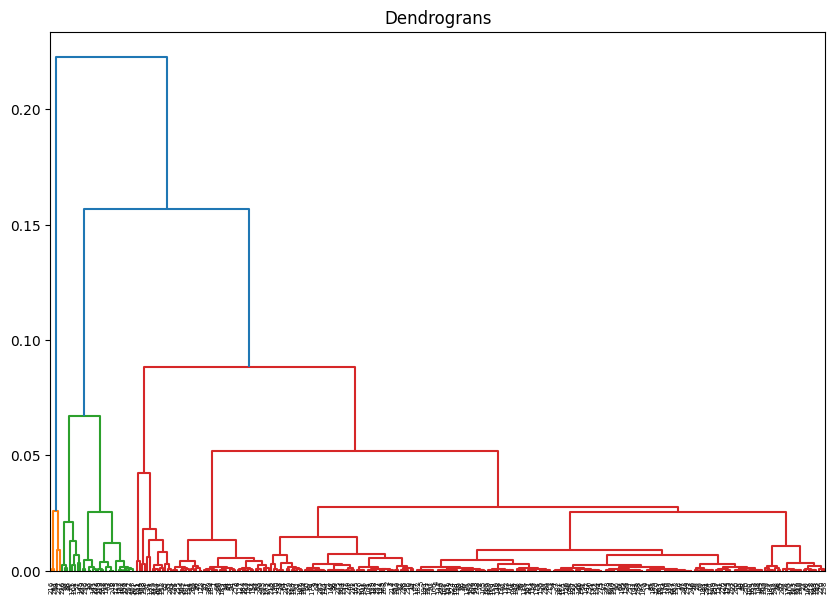

In [ ]:
#drawing the dendrogram that helps to decide the number of clusters.

#for this particular problem

import scipy.cluster.hierarchy as shc

plt.figure(figsize=(10, 7))

plt.title("Dendrograns")

dend = shc.dendrogram(shc.linkage(data_scaled, method="ward"))

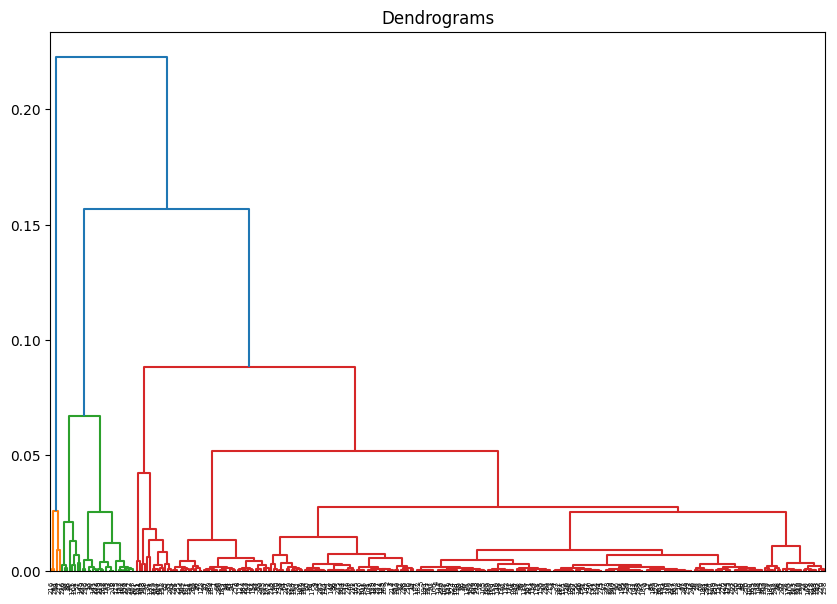

In [ ]:
#The x-axis contains the samples and y-axis represents the

#distance between these samples.

#The vertical line with maximum distance is the blue line and

#hence we can decide a threshold of 6 and cut the dendrogram

plt.figure(figsize=(10, 7))

plt.title("Dendrograms")

dend = shc.dendrogram (shc.linkage(data_scaled, method="ward"))

plt.axhline(y=6, color='r', linestyle='--')



In [ ]:
#the values of es and is in the output since we defined 2 clusters.

#8 represents the points that belong to the first cluster

#and 1 represents points in the second cluster

from sklearn.cluster import AgglomerativeClustering

cluster = AgglomerativeClustering(n_clusters=2, linkage='ward')

cluster.fit_predict(data_scaled)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

Text(0.5, 1.0, 'Clusters of Customers based on Normalized Quantity and Total Amount')

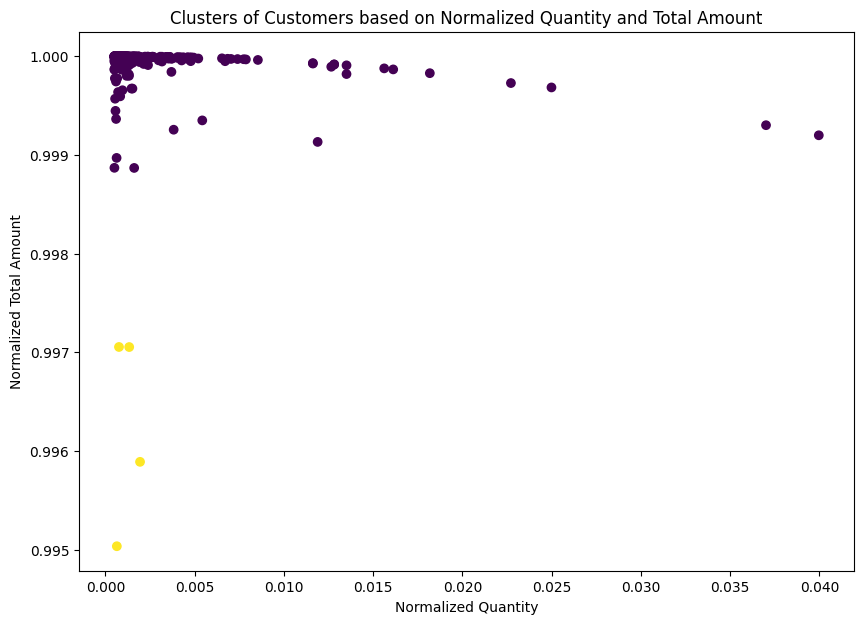

In [ ]:
#visualizing the two clusters

plt.figure(figsize=(10, 7))

# Using 'Quantity' and 'Total_Amount' from data_scaled for visualization
plt.scatter(data_scaled['Quantity'], data_scaled['Total_Amount'], c=cluster.labels_)
plt.xlabel('Normalized Quantity')
plt.ylabel('Normalized Total Amount')
plt.title('Clusters of Customers based on Normalized Quantity and Total Amount')